# DeSCENT Pipeline Demo

**De**convolution-guided **S**ingle-**C**ell **E**xpression for Survival Predictio**N** using **T**ranscriptomics

This notebook walks through the DeSCENT pipeline on **BRCA** (breast cancer). DEG lists are assumed to be pre-computed (via `run_deg_cv.py` or provided externally).

### Data Flow
```
bulk RNA-seq + scRNA-seq reference
        │
        ▼
   Step 1: ReDeconv ──► cell fractions
        │
        ▼
   Step 2: scDiffusion condgen ──► synthetic scGEP (.npz)
        │
        ▼
   Step 3: Multimodal survival CV (bulk + scGEP + DEG) ──► C-index
```

### Prerequisites
- `conda activate descent` (see `environment.yml`)
- GPU with ≥16 GB VRAM recommended
- Data files under `data/BRCA/` and pre-computed DEG files (global or per-fold)

## Environment & Configuration

In [1]:
import os, json
from pathlib import Path

# --- Project root & environment ---
DESCENT_ROOT = Path("/data/zhaoyh/DeSCENT").resolve()
os.chdir(DESCENT_ROOT)
os.environ["DESCENT_ROOT"] = str(DESCENT_ROOT)

# Fix CXXABI_1.3.15 errors on older systems
conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix and Path(conda_prefix, "lib").is_dir():
    ld = os.environ.get("LD_LIBRARY_PATH", "")
    os.environ["LD_LIBRARY_PATH"] = f"{conda_prefix}/lib:{ld}" if ld else f"{conda_prefix}/lib"

# --- Cancer type (change to run other cancers) ---
CANCER = "BRCA"

# --- Load config ---
with open(DESCENT_ROOT / "config" / "path_local.json") as f:
    CONFIG = json.load(f)
cfg = CONFIG[CANCER]

print(f"DESCENT_ROOT : {DESCENT_ROOT}")
print(f"CANCER       : {CANCER}")
print(f"Config keys  : {list(cfg.keys())}")

DESCENT_ROOT : /data/zhaoyh/DeSCENT
CANCER       : BRCA
Config keys  : ['cancer', 'single_cell_data', 'VAE', 'diffusion_backbone', 'classifier', 'sc_npz', 'bulk', 'surv_label', 'deg', 'gene_list', 'celltypes', 'redeconv_ref', 'bulk_tpm', 'bulk_recount3_dir', 'gene_list_path']


In [2]:
import subprocess, gc, torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def gpu_cleanup():
    """Clear GPU memory between pipeline steps (mirrors shell scripts)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [6]:
def resolve(p):
    """Resolve a config path relative to DESCENT_ROOT."""
    if not p:
        return None
    p = Path(p)
    return p if p.is_absolute() else (DESCENT_ROOT / p)

# Verify key data files exist
checks = {
    "bulk_tpm":      resolve(cfg["bulk_tpm"]),
    "surv_label":    resolve(cfg["surv_label"]),
    "gene_list":     resolve(cfg["gene_list"]),
    "VAE":           resolve(cfg["VAE"]),
    "diffusion":     resolve(cfg["diffusion_backbone"]),
    "classifier":    resolve(cfg["classifier"]),
    "redeconv_ref":  resolve(cfg["redeconv_ref"]),
    "sc_npz":        resolve(cfg["sc_npz"]),
    "deg (global)":  resolve(cfg.get("deg", "")),
}

all_ok = True
for name, path in checks.items():
    if path is None:
        status = "⚠ not configured"
        all_ok = False
    elif path.exists():
        status = "✓"
    else:
        status = f"✗ missing: {path}"
        all_ok = False
    print(f"  {name:16s} {status}")

tcga_umi = Path("/data/youzy/tcga_umi") / f"{CANCER.lower()}.csv"
print(f"  {'tcga_umi':16s} {'✓' if tcga_umi.exists() else '✗ missing: ' + str(tcga_umi)}")

print(f"\n{'All files present.' if all_ok else 'Some files missing — affected steps will fail.'}")

  bulk_tpm         ✓
  surv_label       ✓
  gene_list        ✓
  VAE              ✓
  diffusion        ✓
  classifier       ✓
  redeconv_ref     ✓
  sc_npz           ✓
  deg (global)     ✓
  tcga_umi         ✓

All files present.


## Step 1 — ReDeconv (Cell Fraction Estimation)

Estimate cell-type fractions from bulk RNA-seq using the bundled **ReDeconv** (patched fork).

- **Input**: scRNA-seq reference (`Meta_data_new.tsv`, `scRNA_seq_new_noShift.tsv`), bulk TPM
- **Output**: `output/redeconv_fraction/{CANCER}/{CANCER}_ratios_redeconv_10.csv`
- **Note**: Do NOT `pip install redeconv` — it overwrites the local patches.

In [4]:
REDECONV_OUT = str(DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER)
os.makedirs(REDECONV_OUT, exist_ok=True)

print(f"ReDeconv output: {REDECONV_OUT}")

!cd scgep_generation && python pipeline_scripts/run_redeconv_full.py \
    --cancer "{CANCER}" \
    --config "{DESCENT_ROOT}/config/path_local.json" \
    --out_dir "{REDECONV_OUT}"

gpu_cleanup()
print(f"\n→ Expected output: {REDECONV_OUT}/{CANCER}_ratios_redeconv_10.csv")

ReDeconv output: /data/zhaoyh/DeSCENT/output/redeconv_fraction/BRCA


[BRCA] Step 1: Find initial signature genes...
--- Counts of different cell types ---
 +++ Endothelial 	 7495
 +++ CAFs 	 6406
 +++ PVL 	 5175
 +++ B-cells 	 3206
 +++ T-cells 	 35122
 +++ Myeloid 	 9518
 +++ Normal Epithelial 	 4355
 +++ Plasmablasts 	 3524
 +++ Cancer Epithelial 	 24489
CID3586_AAGACCTCAGCATGAG Endothelial
CID3586_AAGGTTCGTAGTACCT Endothelial
CID3586_ACCAGTAGTTGTGGCC Endothelial
CID3586_ACCCACTAGATGTCGG Endothelial
--Grp: Endothelial 7495
--Grp: CAFs 6406
--Grp: PVL 5175
--Grp: B-cells 3206
--Grp: T-cells 35122
--Grp: Myeloid 9518
--Grp: Normal Epithelial 4355
--Grp: Plasmablasts 3524
--Grp: Cancer Epithelial 24489
---Total sample: 99290
--- Processing row:  100  gene:  DFFB
--- Processing row:  200  gene:  RP11-474O21.5
--- Processing row:  300  gene:  WNT4
--- Processing row:  400  gene:  FGR
--- Processing row:  500  gene:  ZMYM4
--- Processing row:  600  gene:  YBX1
--- Processing row:  700  gene:  RP11-330M19.1
--- Processing row:  800  gene:  FOXD3-AS1
--- Proc

### ReDeconv Results Inspection

Shape: 1111 samples × 9 cell types
Cell types: ['B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'Plasmablasts', 'T-cells']



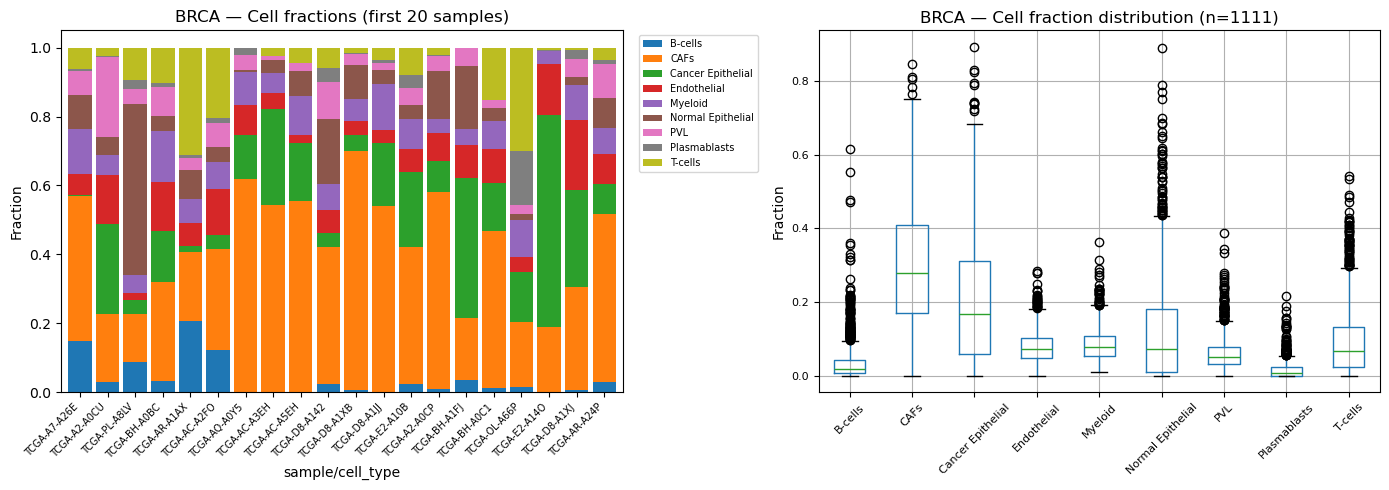

In [7]:
frac_path = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_redeconv_10.csv"

if not frac_path.exists():
    print(f"Fraction file not found: {frac_path} — run Step 1 first.")
else:
    frac_df = pd.read_csv(frac_path, index_col=0)
    print(f"Shape: {frac_df.shape[0]} samples × {frac_df.shape[1]} cell types")
    print(f"Cell types: {list(frac_df.columns)}\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left: Stacked bar (first 20 samples) ---
    plot_df = frac_df.iloc[:20]
    plot_df.plot.bar(stacked=True, ax=axes[0], legend=False, width=0.85)
    axes[0].set_ylabel("Fraction")
    axes[0].set_title(f"{CANCER} — Cell fractions (first 20 samples)")
    axes[0].set_xticklabels([s[:12] for s in plot_df.index], rotation=45, ha="right", fontsize=7)
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

    # --- Right: Box plot of fractions across all samples ---
    frac_df.boxplot(ax=axes[1], rot=45, fontsize=8)
    axes[1].set_ylabel("Fraction")
    axes[1].set_title(f"{CANCER} — Cell fraction distribution (n={len(frac_df)})")

    plt.tight_layout()
    plt.show()

## Step 2 — Conditional scGEP Generation (scDiffusion)

Generate synthetic single-cell gene expression profiles using the diffusion model conditioned on cell-type fractions from ReDeconv.

- **Input**: Cell fractions CSV, pretrained VAE / diffusion backbone / classifier checkpoints
- **Output**: `output/scgep_condgen/{CANCER}/redeconv/cells_2048_{sample_id}/{type_idx}.npz`
- **Demo mode**: Uses first 4 samples (`head -4`) for speed, matching the shell script behavior. For full runs, skip the mini-fraction step.

In [6]:
# Prepare mini fractions (4 samples) for demo speed
frac_full = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_redeconv_10.csv"
frac_mini = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_mini.csv"

if frac_full.exists():
    df_frac = pd.read_csv(frac_full)
    df_frac.head(4).to_csv(frac_mini, index=False)
    print(f"Mini fractions: {frac_mini} ({len(df_frac.head(4))} samples)")
else:
    print(f"Full fractions not found: {frac_full} — run Step 1 first.")

# Resolve model checkpoint paths (same logic as shell script)
def resolve_cfg_path(key):
    p = cfg[key]
    if not p:
        return p
    pp = Path(p)
    return str(pp if pp.is_absolute() else (DESCENT_ROOT / pp).resolve())

MODEL_PATH      = resolve_cfg_path("diffusion_backbone")
CLASSIFIER_PATH = resolve_cfg_path("classifier")
VAE_PATH        = resolve_cfg_path("VAE")
GENE_ORDER      = str(DESCENT_ROOT / "data" / CANCER / "refs" / f"{CANCER}_gene_order.csv")
CONDGEN_OUT     = str(DESCENT_ROOT / "output" / "scgep_condgen" / CANCER / "redeconv")

print(f"model_path      : {MODEL_PATH}")
print(f"classifier_path : {CLASSIFIER_PATH}")
print(f"vae_path        : {VAE_PATH}")
print(f"gene_order      : {GENE_ORDER}")
print(f"out_dir         : {CONDGEN_OUT}")

Mini fractions: /data/zhaoyh/DeSCENT/output/redeconv_fraction/BRCA/BRCA_ratios_mini.csv (4 samples)
model_path      : /data/zhaoyh/DeSCENT/data/BRCA/models/diffusion_backbone.pt
classifier_path : /data/zhaoyh/DeSCENT/data/BRCA/models/classifier.pt
vae_path        : /data/zhaoyh/DeSCENT/data/BRCA/models/VAE.pt
gene_order      : /data/zhaoyh/DeSCENT/data/BRCA/refs/BRCA_gene_order.csv
out_dir         : /data/zhaoyh/DeSCENT/output/scgep_condgen/BRCA/redeconv


In [7]:
!cd scgep_generation && python generate_bulk_from_diffusion.py \
    --model_path "{MODEL_PATH}" \
    --classifier_path "{CLASSIFIER_PATH}" \
    --vae_path "{VAE_PATH}" \
    --cell_ratios_file "{frac_mini}" \
    --num_class 9 \
    --out_dir "{CONDGEN_OUT}" \
    --cell_counts 2048 \
    --num_genes 17930 \
    --gene_order_file "{GENE_ORDER}"

gpu_cleanup()
print(f"\n→ Output: {CONDGEN_OUT}/")

/data/zhaoyh/DeSCENT/scgep_generation/generate_bulk_from_diffusion.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(vae_path, map_

### Condgen Results Inspection

In [8]:
condgen_dir = DESCENT_ROOT / "output" / "scgep_condgen" / CANCER / "redeconv"
sample_dirs = sorted([d for d in condgen_dir.glob("cells_2048_*") if d.is_dir()])

if not sample_dirs:
    print(f"No generated samples found in {condgen_dir} — run Step 2 first.")
else:
    print(f"Generated samples: {len(sample_dirs)}\n")
    for sd in sample_dirs[:4]:
        npz_files = list(sd.glob("*.npz"))
        total_cells = 0
        latent_dim = None
        for npz_f in npz_files:
            data = np.load(npz_f, allow_pickle=True)
            if "cell_gen" in data:
                arr = data["cell_gen"]
                total_cells += arr.shape[0]
                if latent_dim is None:
                    latent_dim = arr.shape[1]
        sample_id = sd.name.replace("cells_2048_", "")
        print(f"  {sample_id}: {len(npz_files)} cell types, "
              f"{total_cells} cells, latent_dim={latent_dim}")

Generated samples: 4

  TCGA-A2-A0CU-01A-12R-A034-07: 9 cell types, 2044 cells, latent_dim=128
  TCGA-A7-A26E-01B-06R-A277-07: 9 cell types, 2042 cells, latent_dim=128
  TCGA-BH-A0BC-01A-22R-A084-07: 9 cell types, 2044 cells, latent_dim=128
  TCGA-PL-A8LV-01A-21R-A41B-07: 9 cell types, 2042 cells, latent_dim=128


## Step 3 — Multimodal Survival Prediction (5-fold CV)

Train a MIL-based multimodal model that fuses bulk RNA-seq with generated single-cell profiles for survival prediction. Evaluated via concordance index (C-index) across 5 folds.

- **Input**: Pre-generated scGEP (`.npz`), bulk expression, survival labels, DEGs
- **Output**: `output/survival_cv/{CANCER}/fold{1..5}/` (model checkpoints, history, loss plots)
- **Epochs**: 300 for production. Reduce to ~30 for a quick smoke test.
- **Per-fold DEG**: When `output/deg_cv/{CANCER}/` exists, per-fold DEGs are used automatically (no data leakage). Otherwise falls back to the global DEG from config.

In [3]:
# Production: 300 epochs. For a quick demo, set EPOCHS = 10.
EPOCHS = 300

# Check for per-fold DEG directory
DEG_DIR = DESCENT_ROOT / "output" / "deg_cv" / CANCER
DEG_ARGS = ""
if DEG_DIR.is_dir() and list(DEG_DIR.glob("degs_fold*.csv")):
    DEG_ARGS = f'--deg_dir "{DEG_DIR}"'
    print(f"Using per-fold DEG from {DEG_DIR}")
else:
    print("Per-fold DEG not found; using global deg from config")

print(f"Epochs: {EPOCHS}")

!python survival_prediction/scrna_bulk_sc_survival_cv.py \
    --cancer "{CANCER}" \
    --config config/path_local.json \
    {DEG_ARGS} \
    --epochs {EPOCHS} \
    --num_folds 5

gpu_cleanup()
print(f"\n→ Output: output/survival_cv/{CANCER}/")

Using per-fold DEG from /data/zhaoyh/DeSCENT/output/deg_cv/BRCA
Epochs: 300
Namespace(config='config/path_local.json', cancer='BRCA', sc_npz_root='/data/zhaoyh/DeSCENT/output/BRCA_2048', gene_list_csv='/data/zhaoyh/DeSCENT/data/BRCA/refs/BRCA_gene_order.csv', deg_csv='', deg_dir='/data/zhaoyh/DeSCENT/output/deg_cv/BRCA', bulk_dir='/data/zhaoyh/DeSCENT/data/BRCA/bulk', results_dir='/data/zhaoyh/DeSCENT/output/survival_cv/BRCA', surv_label_dir='/data/zhaoyh/DeSCENT/data/BRCA/surv_label', vae_ckpt_path='/data/zhaoyh/DeSCENT/data/BRCA/models/VAE.pt', vae_num_genes=17930, epochs=300, batch_size=16, max_cells=2048, lr=0.0002, weight_decay=0.01, embed_dim=256, num_heads=8, num_layers=2, dropout=0.1, alpha_nce=1.0, beta_match=0.5, gamma_mask=0.5, seed=3407, device='cuda', bulk_encoder='vae_mlp', cell_encoder='mil', risk_head='mlp', fusion_type='cross_attn', pooling='attn', ablation='none', loss_fn='cox', num_time_bins=60, time_bins_strategy='quantile', num_folds=5, concat_sc_with_fusion=False,

### Survival Results

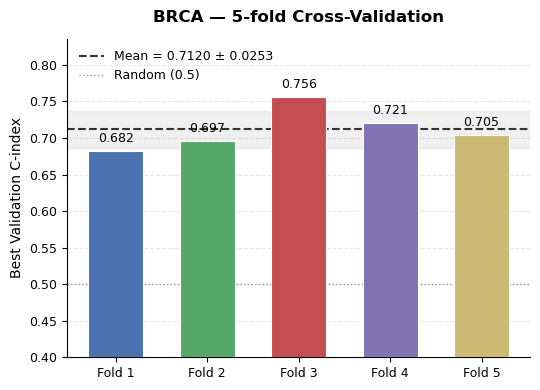


Mean best val C-index: 0.7120 ± 0.0253

Fold 1 training curves (output/survival_cv/BRCA/fold1/losses.png):


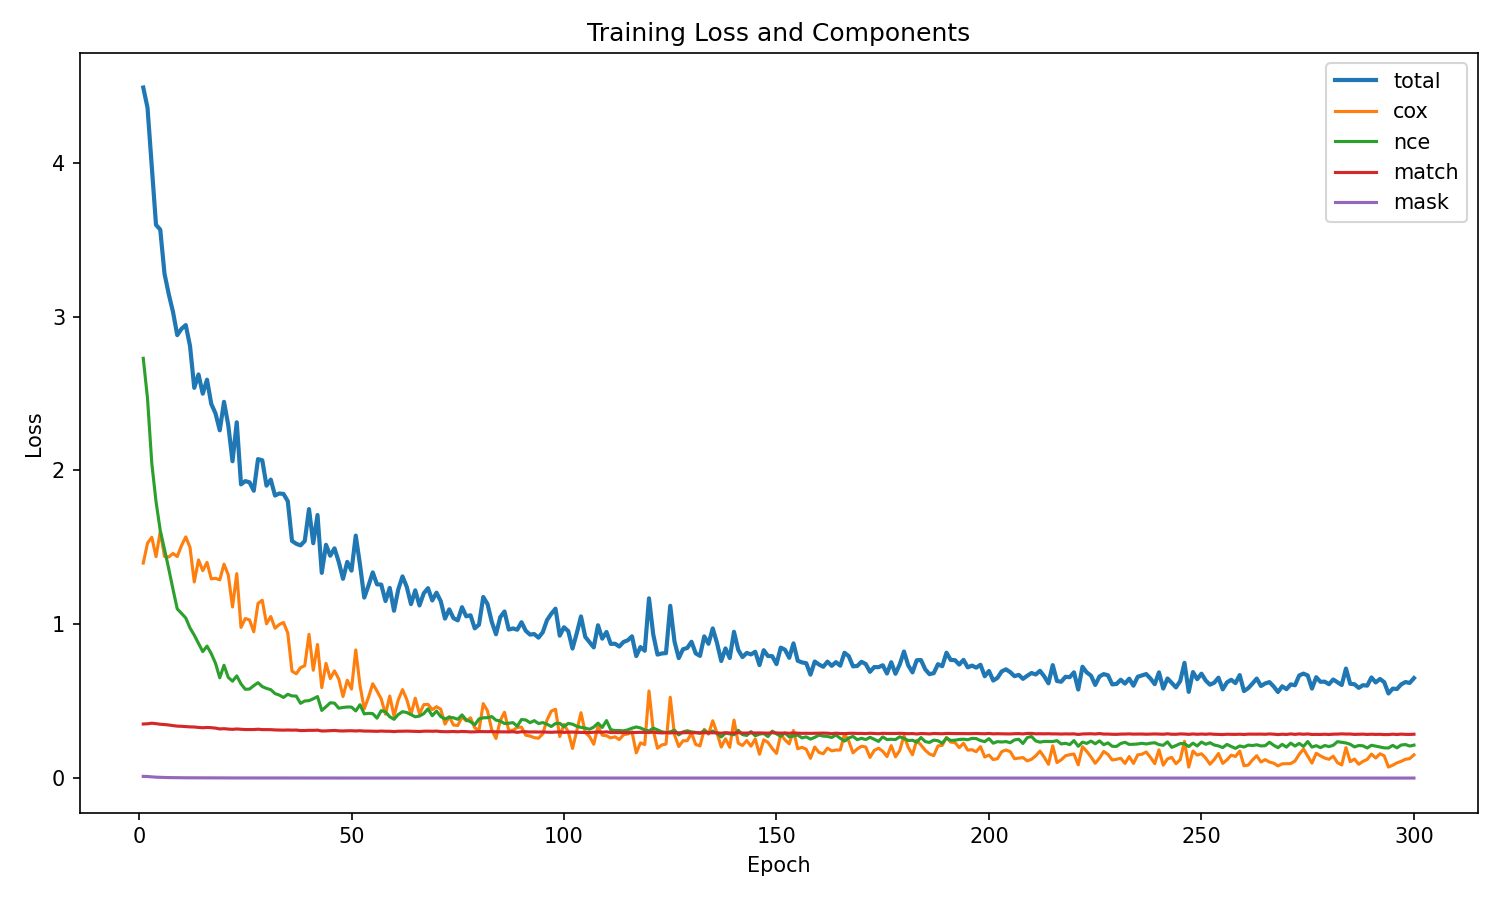

In [4]:
from IPython.display import Image, display
import matplotlib.ticker as mticker

surv_dir = DESCENT_ROOT / "output" / "survival_cv" / CANCER
summary_path = surv_dir / "cv_summary.json"

if not summary_path.exists():
    print(f"Summary not found: {summary_path} — run Step 3 first.")
else:
    with open(summary_path) as f:
        summary = json.load(f)

    folds = summary["folds"]
    mean_ci = summary["mean_best_val_c_index"]
    std_ci  = summary["std_best_val_c_index"]
    fold_nums = [int(m["fold"]) for m in folds]
    cis = [m["best_val_c_index"] for m in folds]

    # --- Publication-quality C-index bar chart ---
    fig, ax = plt.subplots(figsize=(5.5, 4))

    palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    bars = ax.bar([f"Fold {f}" for f in fold_nums], cis,
                  color=palette, edgecolor='white', linewidth=0.8, width=0.6, zorder=3)

    ax.axhline(mean_ci, ls='--', lw=1.5, c='#333333', zorder=2,
               label=f'Mean = {mean_ci:.4f} ± {std_ci:.4f}')
    ax.axhspan(mean_ci - std_ci, mean_ci + std_ci,
               color='#333333', alpha=0.07, zorder=1)
    ax.axhline(0.5, ls=':', lw=1, c='#999999', zorder=2, label='Random (0.5)')

    for bar, v in zip(bars, cis):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='medium')

    ax.set_ylabel('Best Validation C-index', fontsize=10)
    ax.set_title(f'{CANCER} — 5-fold Cross-Validation', fontsize=12, fontweight='bold', pad=12)
    ax.set_ylim(0.4, max(cis) + 0.08)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(axis='y', alpha=0.3, ls='--', zorder=0)

    plt.tight_layout()
    plt.show()

    print(f"\nMean best val C-index: {mean_ci:.4f} ± {std_ci:.4f}")

    # --- Training curves (pre-generated by the survival script) ---
    losses_png = surv_dir / "fold1" / "losses.png"
    if losses_png.exists():
        print(f"\nFold 1 training curves ({losses_png.relative_to(DESCENT_ROOT)}):")
        display(Image(filename=str(losses_png)))
    else:
        print(f"\nlosses.png not found at {losses_png}")

## Summary

| Step | Script | Output |
|------|--------|--------|
| 1. ReDeconv | `scgep_generation/pipeline_scripts/run_redeconv_full.py` | `output/redeconv_fraction/{CANCER}/` |
| 2. Condgen | `scgep_generation/generate_bulk_from_diffusion.py` | `output/scgep_condgen/{CANCER}/redeconv/` |
| 3. Survival CV | `survival_prediction/scrna_bulk_sc_survival_cv.py` | `output/survival_cv/{CANCER}/cv_summary.json` |

DEG lists are assumed pre-computed. To generate per-fold DEGs, run `./scripts/run_deg_all_cancers.sh {CANCER}` before this notebook.

### Shell script equivalents

```bash
# ReDeconv + Condgen
./scripts/run_part1_deg_redeconv_condgen.sh BRCA

# Survival CV
./scripts/run_part2_survival.sh BRCA

# Full pipeline
./scripts/run_full_pipeline_test.sh BRCA
```